In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define experiment and plot settings
experiment_name = 'cell-mitosis-classifier-training'
set_eval = 'eval'  # For evaluation data
set_train = 'train'  # For training data
plot = 'loss'  # Change this to 'loss' if you want to plot loss

In [3]:
# File paths for training and evaluation data
file_path_eval = f'../../experiments/{experiment_name}/dvclive/plots/metrics/{set_eval}/{plot}.tsv'
file_path_train = f'../../experiments/{experiment_name}/dvclive/plots/metrics/{set_train}/{plot}.tsv'

# Load the accuracy data from the TSV files
data_eval = pd.read_csv(file_path_eval, sep='\t')
data_train = pd.read_csv(file_path_train, sep='\t')

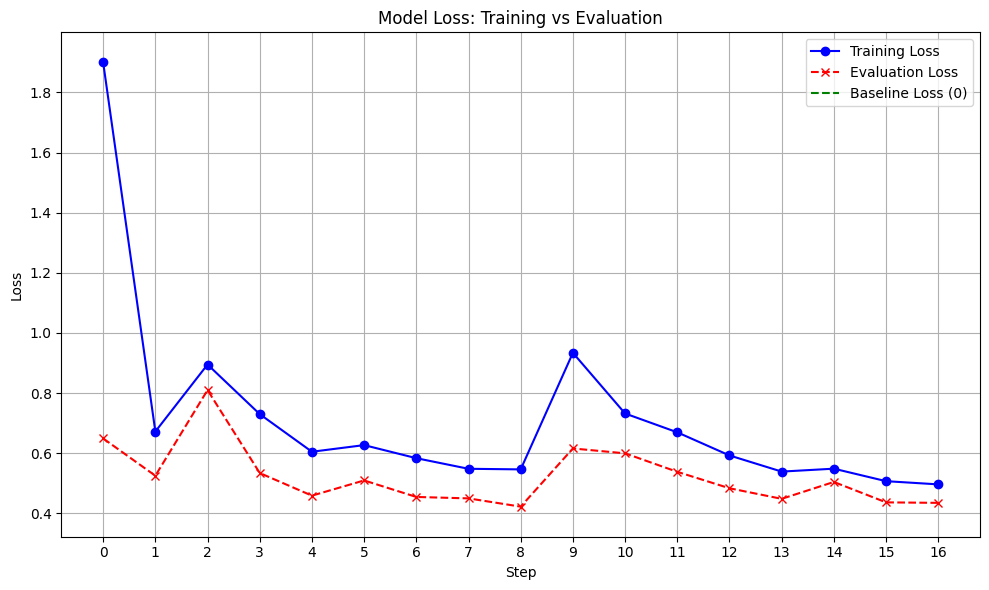

In [4]:
# Plot the accuracy or loss for both training and evaluation
plt.figure(figsize=(10, 6))
plt.plot(data_train['step'], data_train[plot], marker='o', linestyle='-', color='b', label='Training ' + plot.capitalize())
plt.plot(data_eval['step'], data_eval[plot], marker='x', linestyle='--', color='r', label='Evaluation ' + plot.capitalize())

# Customize the plot
plt.title(f'Model {plot.capitalize()}: Training vs Evaluation')
plt.xlabel('Step')
plt.ylabel(plot.capitalize())
plt.xticks(data_train['step'])  # Show all steps on the x-axis
plt.grid()

# Set dynamic y-axis limits based on the data
plt.ylim(min(data_train[plot].min(), data_eval[plot].min()) - 0.1, 
         max(data_train[plot].max(), data_eval[plot].max()) + 0.1)

# Add a horizontal line for baseline if applicable
if plot == 'accuracy':
    plt.axhline(y=0.5, color='g', linestyle='--', label='Baseline Accuracy (0.5)')
elif plot == 'loss':
    plt.axhline(y=0, color='g', linestyle='--', label='Baseline Loss (0)')

plt.legend()
plt.tight_layout()

# Save the plot
# plt.savefig(f'{plot}_plot_train_eval.png')
plt.show()